In [1]:
!pip install transformers torch
from transformers import pipeline

In [6]:
from transformers import pipeline
from transformers import pipeline
senti = pipeline('sentiment-analysis')
reviews = [
'This movie was absolutely breathtaking! A masterpiece.',
'Terrible acting, boring plot. Wasted 2 hours of my life.',
'It was okay. Nothing special but not bad either.',
'Shah Rukh Khan was brilliant. Loved every minute!',
'Ram is more attractive than jayanth ani evaro chepparu',
'KSRM is a great college in asia',
'that movie is not good'
]
results = senti(reviews) # pass a list — processes all at once
for review, result in zip(reviews, results):
  label = result['label'] # 'POSITIVE' or 'NEGATIVE'
  score = result['score'] # confidence: 0.0 to 1.0
  print(f'{label} ({score:.1%}) | {review[:50]}...')
# POSITIVE (99.8%) | This movie was absolutely breathtaking! A masterp...
# NEGATIVE (99.9%) | Terrible acting, boring plot. Wasted 2 hours of m...
# NEGATIVE (55.2%) | It was okay. Nothing special but not bad either....
# POSITIVE (99.1%) | Shah Rukh Khan was brilliant. Loved every minute!.

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

POSITIVE (100.0%) | This movie was absolutely breathtaking! A masterpi...
NEGATIVE (100.0%) | Terrible acting, boring plot. Wasted 2 hours of my...
POSITIVE (99.6%) | It was okay. Nothing special but not bad either....
POSITIVE (100.0%) | Shah Rukh Khan was brilliant. Loved every minute!...
POSITIVE (100.0%) | Ram is more attractive than jayanth ani evaro chep...
POSITIVE (100.0%) | KSRM is a great college in asia...
NEGATIVE (100.0%) | that movie is not good...


In [8]:
from transformers import pipeline
# Zero-shot: classify without any task-specific training
classifier= pipeline('zero-shot-classification',
model='facebook/bart-large-mnli')
text = 'obssesion movie bagundi kani anta horror em ledu'
labels = ['technology','movie','horror','prabas','dq']
result = classifier(text, candidate_labels=labels)
for label, score in zip(result['labels'], result['scores']):
   print(f'{label:15} {score:.1%}')


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

horror          60.7%
movie           34.3%
dq              3.2%
prabas          1.5%
technology      0.2%


In [9]:
import transformers
print(transformers.__file__)
print(transformers.__version__)

/usr/local/lib/python3.12/dist-packages/transformers/__init__.py
5.10.1


In [10]:
!pip install --force-reinstall transformers==4.44.2 tokenizers==0.19.1 --break-system-packages

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
from transformers import pipeline

summariser = pipeline(
    task="summarization",
    model="facebook/bart-large-cnn"
)

long_text = """
The Indian Space Research Organisation (ISRO) successfully launched its
latest Earth observation satellite from the Satish Dhawan Space Centre in
Sriharikota. The satellite carries high-resolution cameras capable of
imaging at 0.5-metre resolution, making it among the most advanced Earth
observation tools deployed. The data will be used for agriculture
monitoring, disaster management, and urban planning.
"""

summary = summariser(
    long_text,
    max_length=20,
    min_length=15,
    do_sample=False,
    truncation=True
)

print(summary[0]["summary_text"])

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


The Indian Space Research Organisation (ISRO) successfully launched its latest Earth observation satellite.


In [2]:
from transformers import pipeline
qa = pipeline('question-answering',
model='deepset/bert-base-cased-squad2')
context = '''
Hi,My name is K.Nomika,from aiml in ksrm college.Currently grtting training on agentic ai and ml for the first time.
I am going to 4 year after this training and i have learnt a lot of things in this training like ml topics and nlp.
today topic is nlp.
'''
questions = [
'which year nomika is going?',
'what she learnt in training?',
'What is today topic?',
]
for q in questions:
  answer = qa(question=q, context=context)
  print(f'Q: {q}')
  print(f'A: {answer["answer"]} (confidence: {answer["score"]:.1%})')
# Q: How many international centuries did Sachin score?
# A: 100 (confidence: 94.2%)

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at deepset/bert-base-cased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/152 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Q: which year nomika is going?
A: 4 (confidence: 50.9%)
Q: what she learnt in training?
A: ml topics and nlp (confidence: 0.0%)
Q: What is today topic?
A: nlp (confidence: 85.4%)


In [18]:
from transformers import pipeline

translator = pipeline(
    "translation",
    model="facebook/nllb-200-distilled-600M"
)

texts = [
    "Hi,My name is K.Nomika,from aiml in ksrm college",
    "today topic is nlp"
]
for text in texts:
    result = translator(
        text,
        src_lang="eng_Latn",
        tgt_lang="tel_Telu"
    )

    print("EN:", text)
    print("TE:", result[0]["translation_text"])
    print()

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


EN: Hi,My name is K.Nomika,from aiml in ksrm college
TE: హలో, నా పేరు K. Nomika, Ksrm కాలేజీ నుండి Aiml నుండి

EN: today topic is nlp
TE: నేటి అంశం nlp



In [13]:
import pandas as pd
from transformers import pipeline
reviews_data = [
# Bollywood
{'movie': '3 Idiots', 'source': 'Bollywood',
'review': 'An absolute masterpiece! Makes you laugh and cry. '
'Aamir Khan delivers one of his finest performances ever.'},
{'movie': '3 Idiots', 'source': 'Bollywood',
'review': 'Overrated and preachy. The message was fine but '
'execution felt too theatrical and unrealistic.'},
{'movie': 'Dangal', 'source': 'Bollywood',
'review': 'Incredibly inspiring! Geeta and Babita brought tears '
'to my eyes. Best sports film ever made in India.'},
{'movie': 'Dangal', 'source': 'Bollywood',
'review': 'Good film but very long. Some scenes dragged unnecessarily.'},
# Hollywood
{'movie': 'Inception', 'source': 'Hollywood',
'review': 'Mind-bending and visually stunning. Nolan at his absolutebest.'},
{'movie': 'Inception', 'source': 'Hollywood',
'review': 'Too complicated. I had no idea what was happening half thetime.'},
{'movie': 'Parasite', 'source': 'Hollywood',
'review': 'Perfect film. The class commentary is brilliant. Deserved everyOscar.'},
{'movie': 'Parasite', 'source': 'Hollywood',
'review': 'I expected more from an Oscar winner. Ending felt rushed.'},
]
df = pd.DataFrame(reviews_data)

In [14]:
# Load once — not inside a loop (that would reload weights every iteration)
sentiment = pipeline('sentiment-analysis',
model='distilbert-base-uncased-finetuned-sst-2-english')
# Batch all reviews at once — faster than one-by-one
results = sentiment(df['review'].tolist())
df['sentiment'] = [r['label'] for r in results] # POSITIVE / NEGATIVE
df['confidence'] = [r['score'] for r in results] # 0.0 to 1.0
# sentiment_score: 1.0 = very positive, 0.0 = very negative
df['sentiment_score'] = df['confidence'].where(
df['sentiment'] == 'POSITIVE',
1 - df['confidence']
)
print(df[['movie','sentiment','confidence']].to_string(index=False))

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

    movie sentiment  confidence
 3 Idiots  POSITIVE    0.999879
 3 Idiots  NEGATIVE    0.999016
   Dangal  POSITIVE    0.999878
   Dangal  NEGATIVE    0.992343
Inception  POSITIVE    0.999849
Inception  NEGATIVE    0.999590
 Parasite  POSITIVE    0.999857
 Parasite  NEGATIVE    0.998913


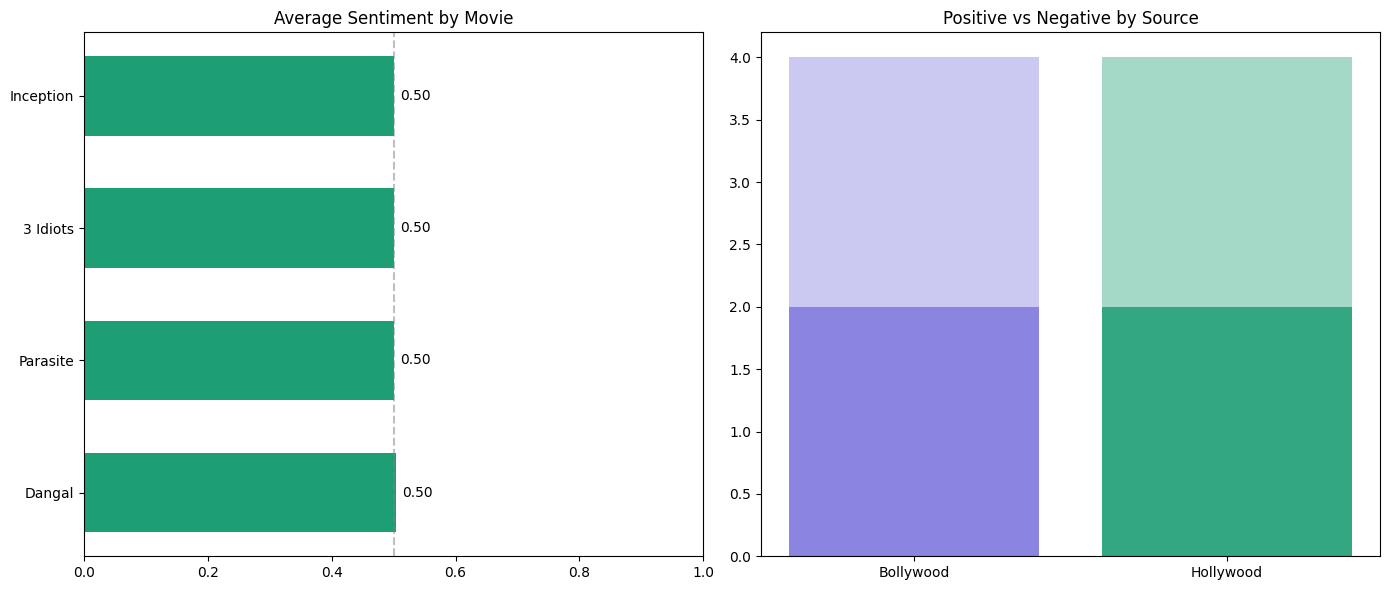

In [15]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Chart 1: Average sentiment score per movie
ax1 = axes[0]
movie_scores =df.groupby('movie')['sentiment_score'].mean().sort_values(ascending=False)
colours = ['#1D9E75' if v >= 0.5 else '#D85A30' for v in
movie_scores.values]
bars = ax1.barh(movie_scores.index, movie_scores.values, color=colours,
height=0.6)
ax1.set_xlim(0, 1)
ax1.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Average Sentiment by Movie')
for bar, val in zip(bars, movie_scores.values):
  ax1.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.2f}',
  va='center')
# Chart 2: Positive vs Negative split by source
  ax2 = axes[1]
for source, colour in [('Bollywood','#7F77DD'), ('Hollywood','#1D9E75')]:
  subset = df[df['source'] == source]
  pos = (subset['sentiment']=='POSITIVE').sum()
  neg = (subset['sentiment']=='NEGATIVE').sum()
  ax2.bar(source, pos, color=colour, alpha=0.9)
  ax2.bar(source, neg, bottom=pos, color=colour, alpha=0.4)
  ax2.set_title('Positive vs Negative by Source')
plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
def analyse_review(review_text, movie_name='Unknown'):
  result = sentiment(review_text)[0]
  label = result['label']
  conf = result['score']
  if label == 'POSITIVE':
    score = conf
    verdict = 'LOVED IT' if conf > 0.95 else 'LIKED IT'
  else:
    score = 1 - conf
    verdict = 'HATED IT' if conf > 0.95 else 'DISLIKED IT'
  print(f'Movie : {movie_name}')
  print(f'Verdict : {verdict}')
  print(f'Score : {score:.1%} positive')
  print(f'Review : {review_text[:80]}...')
  return {'movie': movie_name, 'verdict': verdict, 'score': score}
analyse_review(
'Rajkummar Rao was phenomenal. A raw, honest performance. '
'Easily the best Hindi film of the decade.',
'Stree'
)

Movie : Stree
Verdict : LOVED IT
Score : 100.0% positive
Review : Rajkummar Rao was phenomenal. A raw, honest performance. Easily the best Hindi f...


{'movie': 'Stree', 'verdict': 'LOVED IT', 'score': 0.9998749494552612}